# Vision Transformer

在任何多模态之前，一种图片需要变成一串Transformer可以吃进去的Token。原始的ViT论文使用了16x16像素的补丁块，经过线性投影，叠加位置编码作为答案。现代前沿模型还是一样的，只不过编码器换了，加了Register Token，位置编码变成了2D RoPE。

## 问题描述

Transformer在向量序列上进行操作。文本本身就是一个序列，但是图像则是带3条色彩通道的2D网格，如果你直接把它展平，对于注意力来说，展平后的向量长度就是灾难。

2020年以前的做法是，先做CNN，提取7x7的特征图，每个特征2048维，所以Transformer接受49个Token。这有用，但仍然继承了CNN的先验假设（平移不变形、局部感受野），并且Token数对于Transformer来说太少了。

2020的突破是，直接丢掉CNN，将图像切分成定长大小的块，然后将每个块投影成向量，加一个位置嵌入，就可以喂给原生的Transformer了。

现在，ViT时不容置疑的基础。问题也从“是否应该用补丁切片”变成了“补丁大小怎么选、分辨率怎么选、预训练目标是什么、位置编码用什么”。

## 基本概念

### 补丁用作Token

ViT-B/16的经典配置：
- 分辨率224，补丁大小16，所以生成14x14共196个补丁Token。
- 每个补丁包含16x16x3共768个像素值，投影到768维的潜空间。
- 在头上加一个可学习的[CLS]Token，所以序列总长197。

### 位置编码

补丁没有先后顺序，Transformer能够同时看到他们。早期的Transformer给每个补丁位置加一个可学习的位置编码。有效，但是将模型与分辨率绑死了，推理阶段你需要将图片插值缩放到预设分辨率才能工作。

现代视觉骨架使用2D-RoPE。根据补丁的行、列索引旋转QK向量。所以模型从旋转角度中推测2D相对位置。可以处理任意尺寸的分辨率。

### CLS Token，池化输出以及寄存器Token

图像层级的表征怎么表示？
- [CLS]Token。准备一个可学习的向量，挂到Patch序列中。经过所有的Transformer层之后，它的隐藏状态就是图像表征。从BERT继承过来的，在原始的ViT、CLIP中使用。
- 均值池化。 去所有Patch输出隐状态的平均，在绝大部分现在VLMs中使用。
- 寄存器Tokens。ViT训练过程中有一些Patch上的注意力会异常集中，特征范数特别大，像“垃圾回收点”。这些点不一定对分类有用，却会干扰特征图、分割、稠密预测。所以在Patch序列里再加一个可学习、但不对应任何图像块的额外Token，让模型有张草稿纸写临时注意力噪声。图像Patch的表示更稳、更干净。

### 预训练：监督、对抗、掩码、自蒸馏

2020年ViT被预训练用于做图像分类，之后：
- CLIP：在图文对上对抗训练
- MAE：掩掉75%的Patches，然后进行重建。自监督，在纯图像上工作
- DINO/DINOv2: 自蒸馏。对图像做增强，学生吃一个视图，老师吃另一个视图，然后把学生输出去对齐老师输出。
- SigLIP/SigLIP2：CLIP的损失替换成了Sigmoid，就是说CLIP使用softmax全局归一化，SigLIP做的则是逐对二分类。

预训练的选择决定了骨架适合做什么：CLIP/SigLIP 适合做文本匹配，DINOv2 适合视觉稠密特征，MAE是下游微调任务的良好起点。

# 开始编码

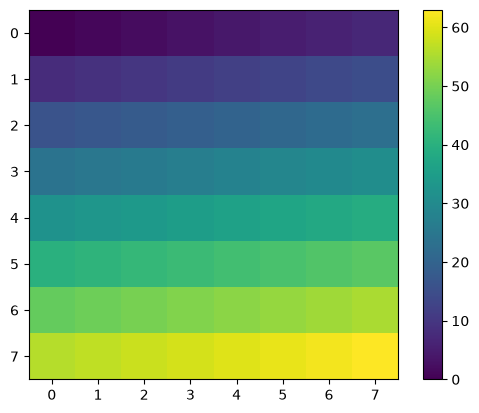

/var/folders/6g/9chj8ddx1033kwmzkbfd95l40000gn/T/ipykernel_9065/1511014818.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


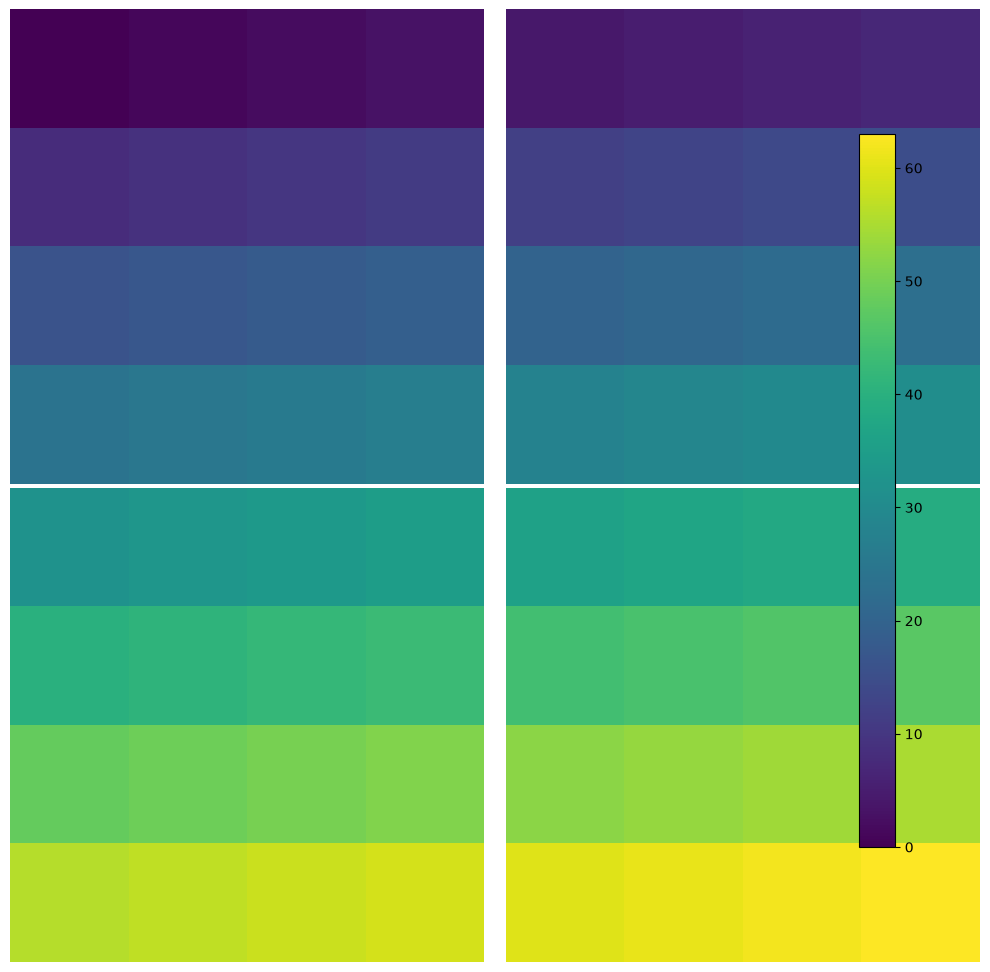

RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x4 and 16x16)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

def patch_toy_image()->None:
    img = np.array([
        [(r * 8. + c) % 256 for c in range(8)]
        for r in range(8)
    ], dtype=float)

    # 原图与所有 patch 共用同一套数值范围
    vmin, vmax = img.min(), img.max()

    plt.imshow(img, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.show()

    P = 4
    patches = []
    for pr in range(0, 8, P):
        for pc in range(0, 8, P):
            patches.append(img[pr:pr + P, pc:pc + P])

    figs, axes = plt.subplots(2, 2, figsize=(10, 10))
    for axis, patch in zip(axes.ravel(), patches):
        im = axis.imshow(patch, vmin=vmin, vmax=vmax)
        axis.set_axis_off()
    # 共用一根 ColorBar（映射与原图一致）
    figs.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    embedding = nn.Linear(P * P, P * P)
    embeded = []
    for patch in patches:
        embeded.append(embedding(torch.tensor(np.array(patch).flatten(), dtype=torch.float32)))

    embeded = torch.stack(embeded)
    print(embeded.shape)
    print(embeded)


patch_toy_image()
